In [1]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

In [2]:
np.random.seed(1)

#### Variational Inference (VI)

In [3]:
# Simulating linear regression data.

n = 100

x = np.random.normal(0, 1, n)

true_intercept = 1.5
true_slope = 2.0
true_sigma = 1.0

y = (
    true_intercept
    + true_slope * x
    + np.random.normal(0, true_sigma, n)
)

print("Sample size:", n)

Sample size: 100


In [4]:
# Building the Bayesian linear regression model.

with pm.Model() as vi_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=10
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=10
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=5
    )

    mu = intercept + slope * x

    outcome = pm.Normal(
        "outcome",
        mu=mu,
        sigma=sigma,
        observed=y
    )

In [5]:
# Fitting the model using Variational Inference.

with vi_model:

    approx = pm.fit(
        n=20000,
        method="advi",
        random_seed=42
    )

Output()

Finished [100%]: Average Loss = 147.41


In [6]:
# Drawing posterior samples from the approximation.

with vi_model:

    vi_trace = approx.sample(2000)

In [7]:
# Posterior summary.

summary = az.summary(
    vi_trace,
    hdi_prob=0.95
)

print(summary)

arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
intercept  1.648  0.107     1.446      1.861      0.002    0.002    2032.0   
slope      2.101  0.127     1.870      2.360      0.003    0.002    1673.0   
sigma      0.956  0.076     0.817      1.109      0.002    0.001    1750.0   

           ess_tail  r_hat  
intercept    1805.0    NaN  
slope        1866.0    NaN  
sigma        1994.0    NaN  


#### Compare Variational Inference (VI) and MCMC

In [8]:
# Fitting the model using MCMC (NUTS).

with vi_model:

    mcmc_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 26 seconds.


In [9]:
# Summarizing posterior estimates.

vi_summary = az.summary(
    vi_trace,
    kind="stats",
    hdi_prob=0.95
)

mcmc_summary = az.summary(
    mcmc_trace,
    hdi_prob=0.95
)

print("Variational Inference:\n", vi_summary)

print("\nMCMC:\n", mcmc_summary)

Variational Inference:
             mean     sd  hdi_2.5%  hdi_97.5%
intercept  1.648  0.107     1.446      1.861
slope      2.101  0.127     1.870      2.360
sigma      0.956  0.076     0.817      1.109

MCMC:
             mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
intercept  1.647  0.096     1.461      1.834      0.001    0.001   11247.0   
slope      2.095  0.106     1.897      2.307      0.001    0.001   11746.0   
sigma      0.949  0.070     0.818      1.089      0.001    0.001   10159.0   

           ess_tail  r_hat  
intercept    6300.0    1.0  
slope        6452.0    1.0  
sigma        6205.0    1.0  


In [12]:
# Comparing parameter estimates.

parameters = ["intercept", "slope", "sigma"]

for parameter in parameters:

    vi_mean = vi_summary.loc[parameter, "mean"]
    mcmc_mean = mcmc_summary.loc[parameter, "mean"]

    print(parameter)
    print("VI mean:", round(vi_mean, 3))
    print("MCMC mean:", round(mcmc_mean, 3))
    print("Difference:", round(abs(vi_mean - mcmc_mean), 3))
    print()

intercept
VI mean: 1.648
MCMC mean: 1.647
Difference: 0.001

slope
VI mean: 2.101
MCMC mean: 2.095
Difference: 0.006

sigma
VI mean: 0.956
MCMC mean: 0.949
Difference: 0.007



Variational Inference


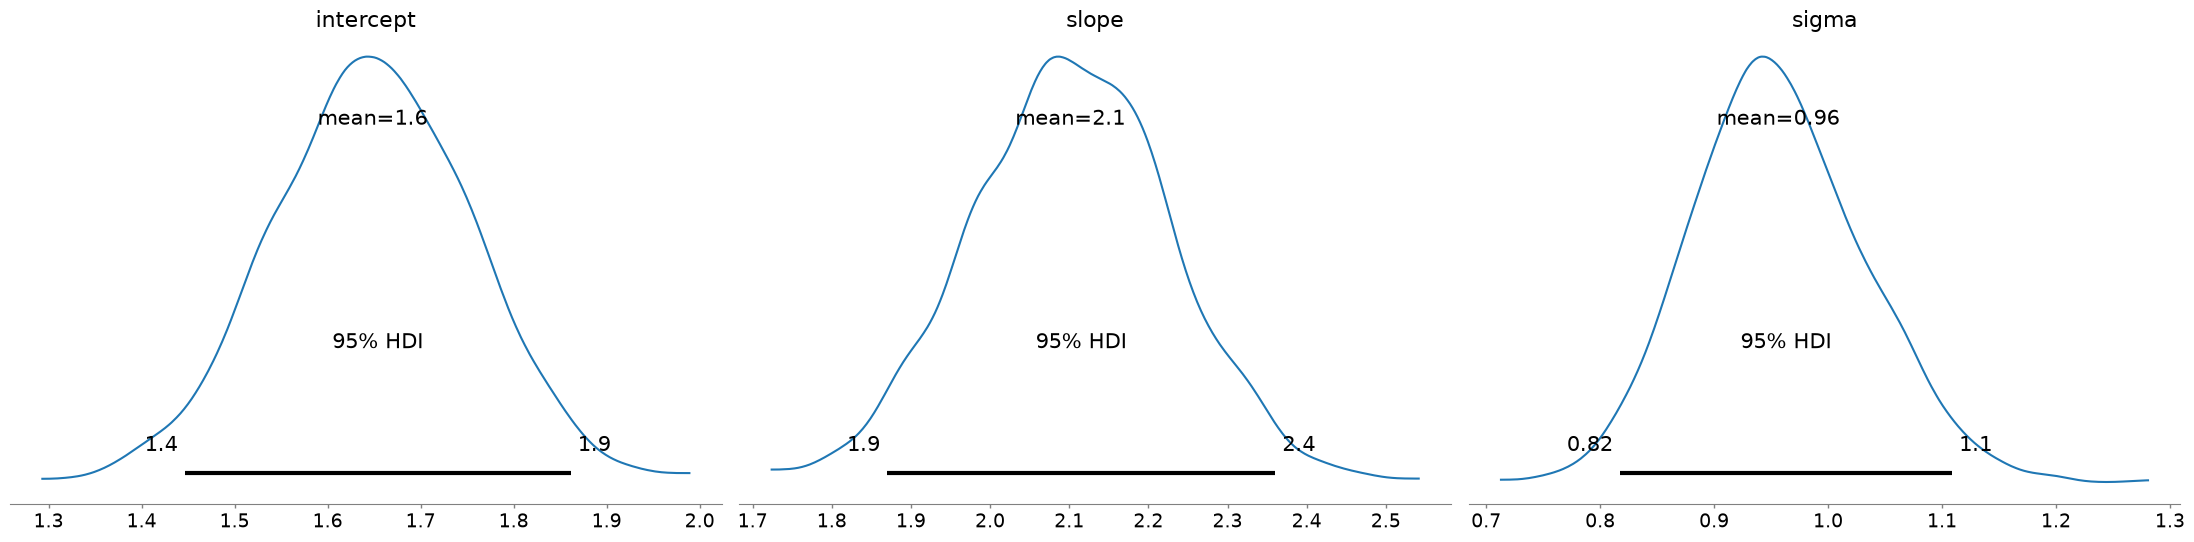


MCMC


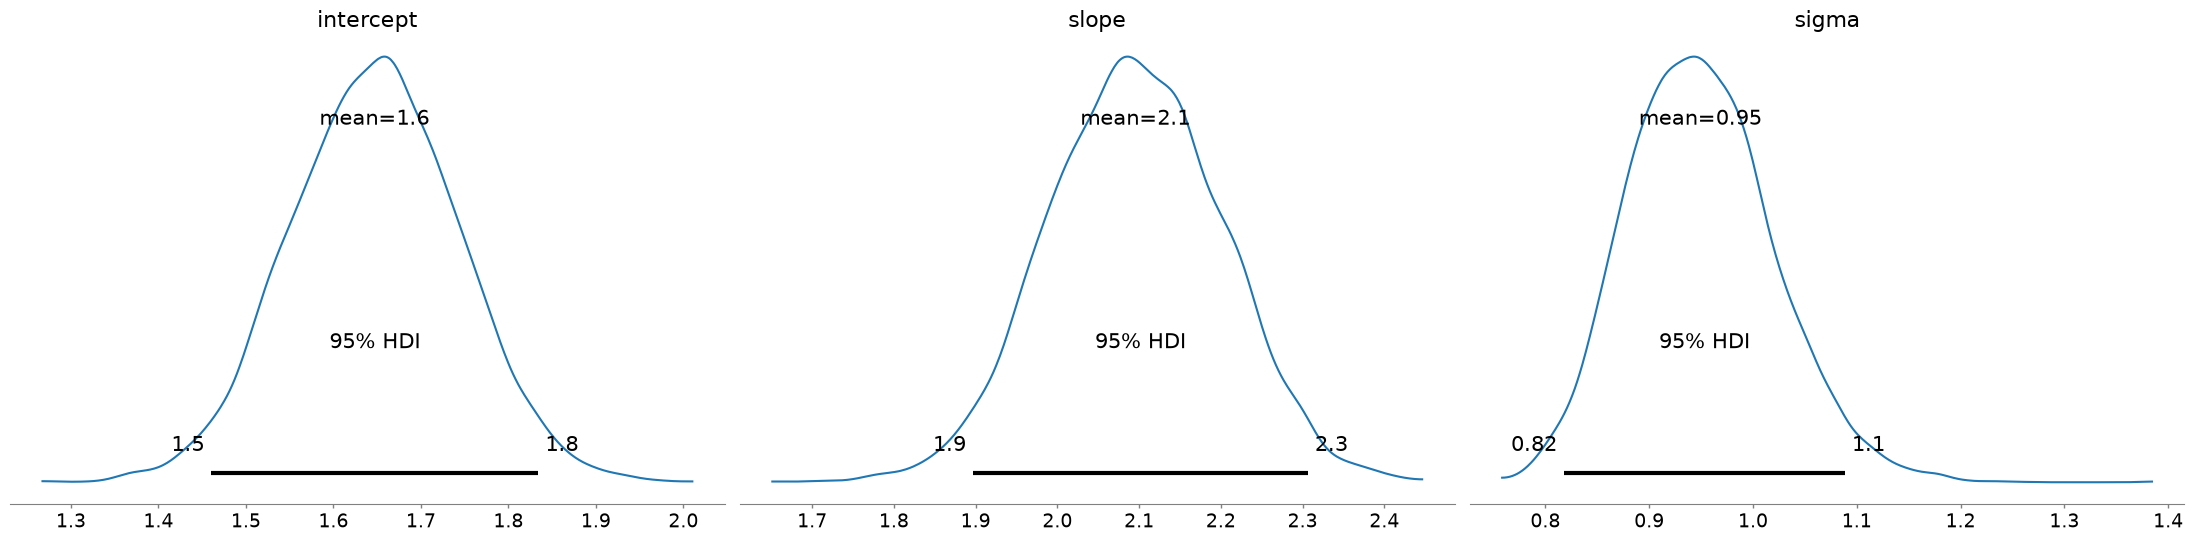

In [15]:
# Visualizing posterior distributions.

parameters = ["intercept", "slope", "sigma"]

print("Variational Inference")
az.plot_posterior(
    vi_trace,
    var_names=parameters,
    hdi_prob=0.95
)

plt.tight_layout()

plt.show()

print("\nMCMC")
az.plot_posterior(
    mcmc_trace,
    var_names=parameters,
    hdi_prob=0.95
)

plt.tight_layout()

plt.show()

Advantages of Variational Inference
- Much faster than MCMC.
- Scales well to large datasets.
- Useful when rapid approximate inference is needed.
- Suitable for complex models where MCMC is computationally expensive.

Limitations of Variational Inference
- Produces an approximate posterior.
- Often underestimates posterior uncertainty.
- May fail to capture correlations between parameters.
- Accuracy depends on the chosen variational family.

Advantages of MCMC
- Produces samples from the true posterior distribution.
- More accurate uncertainty estimates.
- Better suited for complex posterior distributions.

Limitations of MCMC
- Computationally expensive.
- Can require long sampling times.
- Requires convergence diagnostics (R-hat, ESS, trace plots).